# xG-Projekt - 02: Explorative Datenanalyse (EDA)

Untersucht den Datensatz aus Notebook 01, 916 Schüsse aus der
Bayer Leverkusen Saison 2023/2024, auf Verteilungen, Zusammenhänge und Auffälligkeiten


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("../data/shots.csv")
print(df.shape)
df.head(3)


(916, 17)


,match_id,player,team,minute,x,y,distance_to_goal,angle_to_goal,body_part,shot_type,technique,under_pressure,n_defenders_in_cone,gk_distance_to_goal,play_pattern,statsbomb_xg,is_goal
0,3895292,Borja Iglesias Quintas,Bayer Leverkusen,2,107.0,53.4,18.669762,17.365796,Right Foot,Open Play,Half Volley,True,1.0,3.612478,Regular Play,0.084877,0
1,3895292,Granit Xhaka,Bayer Leverkusen,5,96.5,39.9,23.500213,19.319453,Right Foot,Open Play,Normal,True,2.0,2.220360,From Throw In,0.042399,0
2,3895292,Adam Hložek,Bayer Leverkusen,6,88.2,45.5,32.272124,13.932473,Right Foot,Open Play,Normal,True,3.0,2.433105,From Corner,0.017574,0


## 1. Zielvariable: Klassenungleichgewicht

Tore sind die Minderheitsklasse. Muss bei Metrik-Wahl und
Kreuzvalidierung berücksichtigt werden


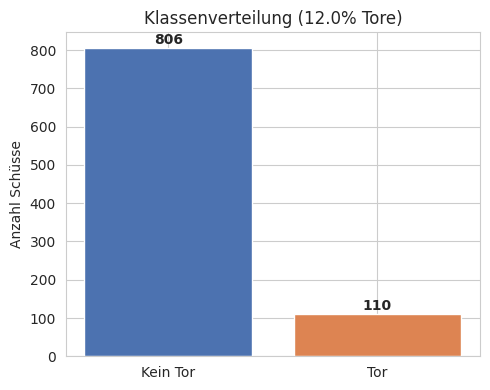

In [2]:
goal_counts = df["is_goal"].value_counts().rename({0: "Kein Tor", 1: "Tor"})
goal_pct = df["is_goal"].mean() * 100

fig, ax = plt.subplots(figsize=(5, 4))
colors = ["#4C72B0", "#DD8452"]
ax.bar(goal_counts.index, goal_counts.values, color=colors)
for i, v in enumerate(goal_counts.values):
    ax.text(i, v + 10, str(v), ha="center", fontweight="bold")
ax.set_ylabel("Anzahl Schüsse")
ax.set_title(f"Klassenverteilung ({goal_pct:.1f}% Tore)")
plt.tight_layout()
plt.savefig("../plots/01_class_balance.png")
plt.show()


## 2. Distanz zum Tor vs. Torwahrscheinlichkeit

Je näher desto wahrscheinlicher ein Tor. Geprüft 
sowohl per Verteilung als auch als empirische Torwahrscheinlichkeitskurve
(gebinnt nach Distanz) quasi schon ein Mini-xG-Modell


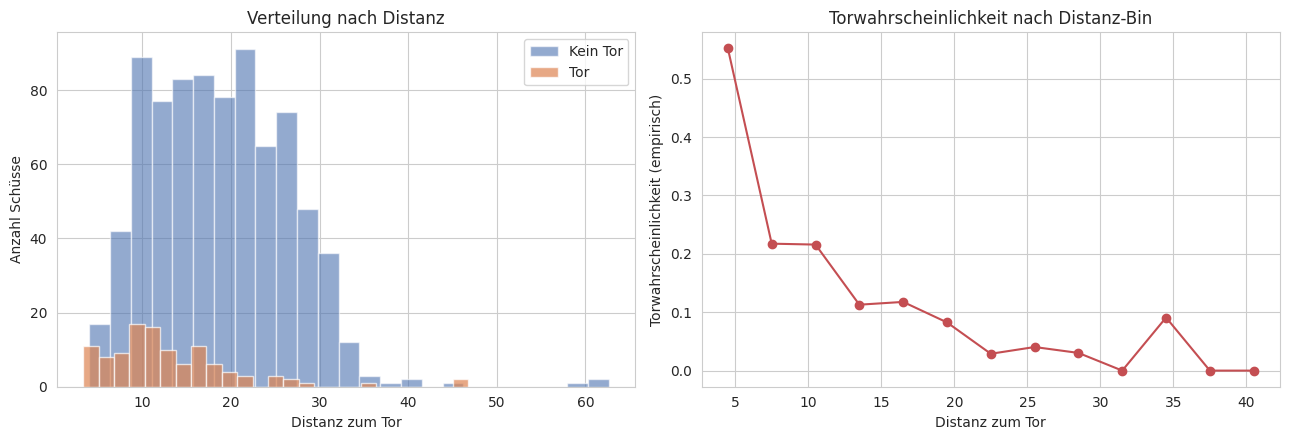

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Verteilung
axes[0].hist(df.loc[df.is_goal == 0, "distance_to_goal"], bins=25, alpha=0.6, label="Kein Tor", color="#4C72B0")
axes[0].hist(df.loc[df.is_goal == 1, "distance_to_goal"], bins=25, alpha=0.7, label="Tor", color="#DD8452")
axes[0].set_xlabel("Distanz zum Tor")
axes[0].set_ylabel("Anzahl Schüsse")
axes[0].set_title("Verteilung nach Distanz")
axes[0].legend()

# Empirische Torwahrscheinlichkeit nach Distanz-Bins
df["distance_bin"] = pd.cut(df["distance_to_goal"], bins=np.arange(0, 45, 3))
prob_by_dist = df.groupby("distance_bin", observed=True)["is_goal"].agg(["mean", "count"])
bin_centers = [interval.mid for interval in prob_by_dist.index]

axes[1].plot(bin_centers, prob_by_dist["mean"], marker="o", color="#C44E52")
axes[1].set_xlabel("Distanz zum Tor")
axes[1].set_ylabel("Torwahrscheinlichkeit (empirisch)")
axes[1].set_title("Torwahrscheinlichkeit nach Distanz-Bin")

plt.tight_layout()
plt.savefig("../plots/02_distance_analysis.png")
plt.show()




## 3. Winkel zum Tor vs. Torwahrscheinlichkeit


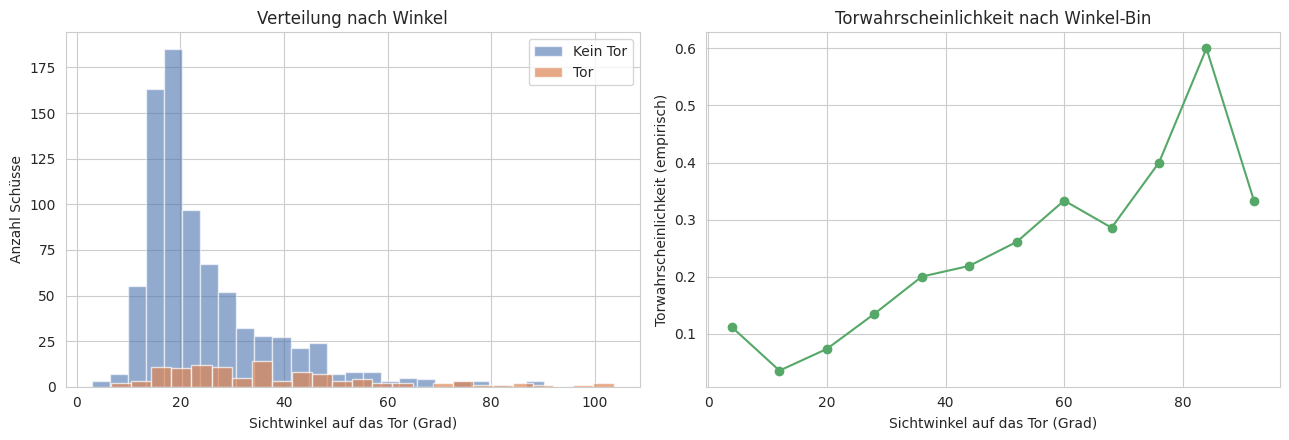

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df.loc[df.is_goal == 0, "angle_to_goal"], bins=25, alpha=0.6, label="Kein Tor", color="#4C72B0")
axes[0].hist(df.loc[df.is_goal == 1, "angle_to_goal"], bins=25, alpha=0.7, label="Tor", color="#DD8452")
axes[0].set_xlabel("Sichtwinkel auf das Tor (Grad)")
axes[0].set_ylabel("Anzahl Schüsse")
axes[0].set_title("Verteilung nach Winkel")
axes[0].legend()

df["angle_bin"] = pd.cut(df["angle_to_goal"], bins=np.arange(0, 100, 8))
prob_by_angle = df.groupby("angle_bin", observed=True)["is_goal"].agg(["mean", "count"])
bin_centers = [interval.mid for interval in prob_by_angle.index]

axes[1].plot(bin_centers, prob_by_angle["mean"], marker="o", color="#55A868")
axes[1].set_xlabel("Sichtwinkel auf das Tor (Grad)")
axes[1].set_ylabel("Torwahrscheinlichkeit (empirisch)")
axes[1].set_title("Torwahrscheinlichkeit nach Winkel-Bin")

plt.tight_layout()
plt.savefig("../plots/03_angle_analysis.png")
plt.show()


## 4. Shot Map – wo auf dem Feld wird geschossen?

Vereinfachter Ausschnitt des Angriffsdrittels, jeder Schuss an
seiner Originalposition, eingefärbt nach Ergebnis geplottet


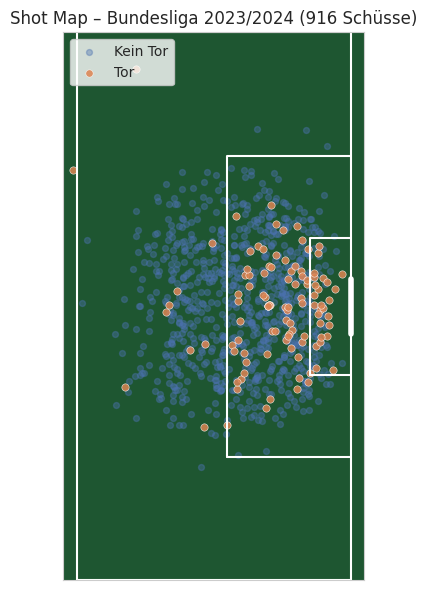

In [ ]:
def draw_pitch_third(ax):
    """Zeichnet das Angriffsdrittel eines Fußballfelds im StatsBomb-Koordinatensystem
    (120x80)"""
    ax.set_facecolor("#1e5631")
    # Spielfeldbegrenzung (rechtes Drittel)
    ax.plot([80, 80], [0, 80], color="white", lw=1.5)
    ax.plot([80, 120, 120, 80], [0, 0, 80, 80], color="white", lw=1.5)
    # Strafraum (18-Yard-Box)
    ax.plot([102, 102, 120], [18, 62, 62], color="white", lw=1.5)
    ax.plot([102, 120], [18, 18], color="white", lw=1.5)
    # Torraum (6-Yard-Box)
    ax.plot([114, 114, 120], [30, 50, 50], color="white", lw=1.5)
    ax.plot([114, 120], [30, 30], color="white", lw=1.5)
    # Elfmeterpunkt
    ax.scatter([108], [40], color="white", s=10)
    # Tor
    ax.plot([120, 120], [36, 44], color="white", lw=4)
    ax.set_xlim(78, 122)
    ax.set_ylim(0, 80)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


fig, ax = plt.subplots(figsize=(8, 6))
draw_pitch_third(ax)

no_goal = df[df.is_goal == 0]
goal = df[df.is_goal == 1]

ax.scatter(no_goal["x"], no_goal["y"], s=18, alpha=0.4, color="#4C72B0", label="Kein Tor")
ax.scatter(goal["x"], goal["y"], s=28, alpha=0.85, color="#DD8452", edgecolor="white", linewidth=0.4, label="Tor")

ax.set_title("Shot Map – Bayer Leverkusen 2023/2024 (916 Schüsse)")
ax.legend(loc="upper left", facecolor="white")
plt.tight_layout()
plt.savefig("../plots/04_shot_map.png")
plt.show()


Deutlich erkennbar: Tore (orange) konzentrieren sich stark im/um den Strafraum und zentral
vor dem Tor, während Schüsse ohne Erfolg (blau) über eine viel größere Fläche gestreut sind,
inklusive vieler Versuche aus großer Distanz oder spitzem Winkel.

## 5. Körperteil & Schusstyp


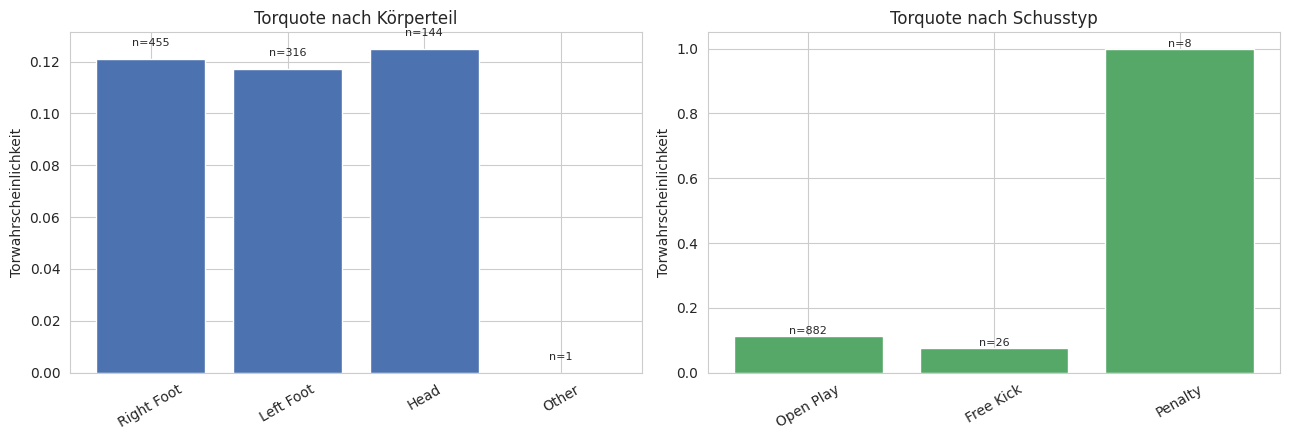

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

body_stats = df.groupby("body_part")["is_goal"].agg(["mean", "count"]).sort_values("count", ascending=False)
axes[0].bar(body_stats.index, body_stats["mean"], color="#4C72B0")
axes[0].set_ylabel("Torwahrscheinlichkeit")
axes[0].set_title("Torquote nach Körperteil")
axes[0].tick_params(axis="x", rotation=30)
for i, (idx, row) in enumerate(body_stats.iterrows()):
    axes[0].text(i, row["mean"] + 0.005, f"n={int(row['count'])}", ha="center", fontsize=8)

type_stats = df.groupby("shot_type")["is_goal"].agg(["mean", "count"]).sort_values("count", ascending=False)
axes[1].bar(type_stats.index, type_stats["mean"], color="#55A868")
axes[1].set_ylabel("Torwahrscheinlichkeit")
axes[1].set_title("Torquote nach Schusstyp")
axes[1].tick_params(axis="x", rotation=30)
for i, (idx, row) in enumerate(type_stats.iterrows()):
    axes[1].text(i, row["mean"] + 0.005, f"n={int(row['count'])}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("../plots/05_bodypart_shottype.png")
plt.show()


## 6. Drucksituation & Gegner im Schusskegel


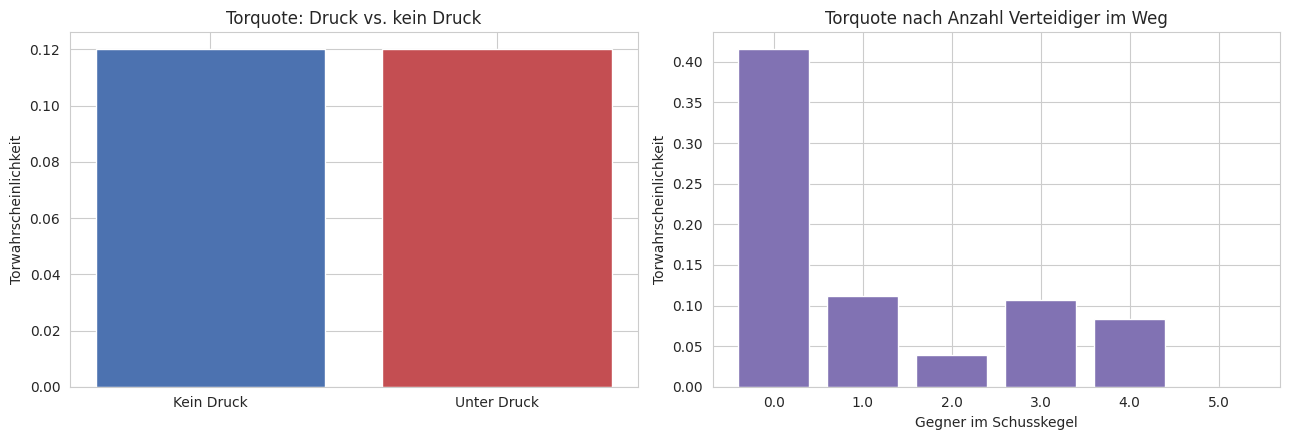

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

pressure_stats = df.groupby("under_pressure")["is_goal"].mean()
axes[0].bar(["Kein Druck", "Unter Druck"], pressure_stats.values, color=["#4C72B0", "#C44E52"])
axes[0].set_ylabel("Torwahrscheinlichkeit")
axes[0].set_title("Torquote: Druck vs. kein Druck")

defenders_stats = df.groupby("n_defenders_in_cone")["is_goal"].agg(["mean", "count"])
defenders_stats = defenders_stats[defenders_stats["count"] >= 5]  # zu kleine Gruppen ausblenden
axes[1].bar(defenders_stats.index.astype(str), defenders_stats["mean"], color="#8172B3")
axes[1].set_xlabel("Gegner im Schusskegel")
axes[1].set_ylabel("Torwahrscheinlichkeit")
axes[1].set_title("Torquote nach Anzahl Verteidiger im Weg")

plt.tight_layout()
plt.savefig("../plots/06_pressure_defenders.png")
plt.show()


Linker Plot ist Nichtsaussagend. Höchstwahrscheinlich auf einen under_pressure Wert, der überall auf "true" gesetzt ist, zurückzuwerten

## 7. Korrelationen zwischen numerischen Features


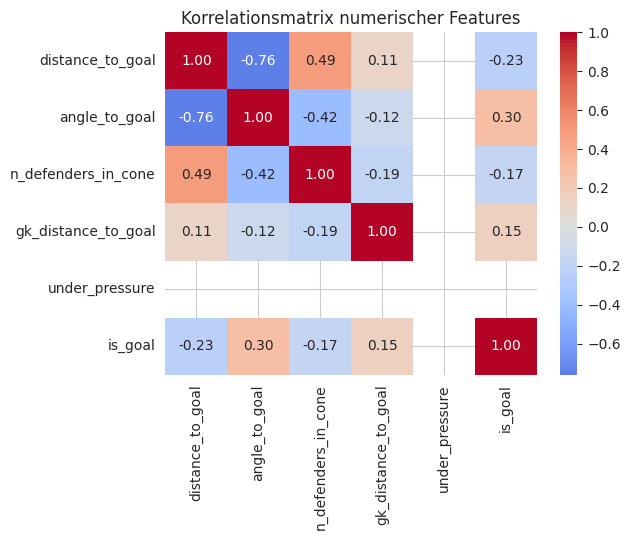

In [8]:
num_cols = ["distance_to_goal", "angle_to_goal", "n_defenders_in_cone",
            "gk_distance_to_goal", "under_pressure", "is_goal"]
corr_df = df[num_cols].copy()
corr_df["under_pressure"] = corr_df["under_pressure"].astype(int)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Korrelationsmatrix numerischer Features")
plt.tight_layout()
plt.savefig("../plots/07_correlation.png")
plt.show()
